In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## DATAFRAME AUTO, ANALISI DATI ANALITICI (Dati presi con scraping)

la prima riga di codice serve per leggere un csv con pandas

In [2]:
data = pd.read_csv("Used_fiat_500_in_Italy_dataset.csv")
data.head()
#Il dataset che stiamo usando è stato fatto con scraping, sono stati cercati dati su diversi siti da un bot

,model,engine_power,transmission,age_in_days,km,previous_owners,lat,lon,price
0,pop,69,manual,4474,56779,2,45.071079,7.46403,4490
1,lounge,69,manual,2708,160000,1,45.069679,7.70492,4500
2,lounge,69,automatic,3470,170000,2,45.514599,9.28434,4500
3,sport,69,manual,3288,132000,2,41.903221,12.49565,4700
4,sport,69,manual,3712,124490,2,45.532661,9.03892,4790


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 380 entries, 0 to 379
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   model            380 non-null    object 
 1   engine_power     380 non-null    int64  
 2   transmission     380 non-null    object 
 3   age_in_days      380 non-null    int64  
 4   km               380 non-null    int64  
 5   previous_owners  380 non-null    int64  
 6   lat              380 non-null    float64
 7   lon              380 non-null    float64
 8   price            380 non-null    int64  
dtypes: float64(2), int64(5), object(2)
memory usage: 26.8+ KB


In [4]:
# Indici statistici (solo per colonne numeriche) Count è il numero di valori, per ogni colonna. Fatto in automatico da pandas
data.describe()

,engine_power,age_in_days,km,previous_owners,lat,lon,price
count,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000,380.000000
mean,73.015789,3310.265789,102196.250000,1.510526,44.257712,10.742644,5881.655263
std,9.984672,1437.555063,47115.355234,0.560244,1.767518,2.167753,2170.617946
min,69.000000,91.000000,4981.000000,1.000000,37.510872,7.320720,2890.000000
25%,69.000000,3097.250000,76611.750000,1.000000,43.514196,9.159140,4600.000000
50%,69.000000,3927.000000,112000.000000,1.000000,45.069679,10.301505,5000.000000
75%,69.000000,4322.000000,135000.000000,2.000000,45.556942,12.346788,5500.000000
max,101.000000,4719.000000,259000.000000,4.000000,46.781651,18.168011,15900.000000


## Come leggere un dataframe con statistiche

Count conta quanti valori ci sono per tali colonne (Le auto sono 380 i valori dovrebbero essere tutti 380 a meno di null?)

mean è la media

std invece è la variazione standard (Quanto variano i valori dalla media...)

min e max sono relativamente minimo e massimo

il 75% delle macchine costano meno di 5500, che significa che il restante 25 dovrebbero essere quelle che costano di più
di questo 75 percento il 50 costa meno di 5000 e il 25 meno di 4600 (Si legge con il minore)

I percentili permettono di dare un andamento anonimo di una classe (volendo)

# Ora facciamo ricerche sul dataframe

un po' come facciamo con sql

In Pandas abbiamo due tipi di oggetti:

* I Dataframe che sono le tabelle di dati
* Le series che sono serie di dati, per esempio una colonna di un dataframe, ma non sono tabelle intere

In [5]:
#tutte le auto che costano meno di 3500 euro
data[data["price"] < 3500]

,model,engine_power,transmission,age_in_days,km,previous_owners,lat,lon,price
98,lounge,69,manual,4596,259000,2,45.027100,12.22086,2890
99,sport,101,automatic,4719,182000,2,41.005520,15.07278,3250
100,lounge,69,automatic,4292,190000,1,41.903221,12.49565,3300
101,pop,69,manual,3957,151000,1,43.550549,11.58833,3400


In [6]:
# i modelli di tutte le auto che costano meno di 3500 euro
data[data["price"] < 3500]["model"] #restituisce una series, non una tabella

98     lounge
99      sport
100    lounge
101       pop
Name: model, dtype: object

In [7]:
# i modelli e i km di tutte le auto che costano meno di 3500 euro
data[data["price"] < 3500][["model", "km"]] #Stiamo facendo delle select, delle query con pandas

,model,km
98,lounge,259000
99,sport,182000
100,lounge,190000
101,pop,151000


## Domanda: il prezzo è legato in qualche modo al kilometraggio?

### Ora facciamo un grafico per esserne certi (attenzione ad allestimenti)

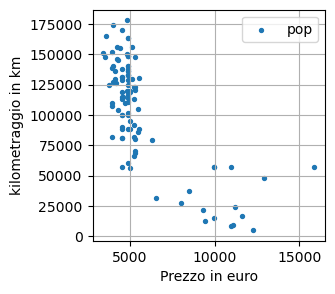

In [8]:
#Selezioniamo tutte quante le pop
model = 'pop'
selected_data = data[data["model"] == model]
price = selected_data["price"].to_numpy() #Prendo la colonna dei prezzi e la metto in un array di numpy per poter fare grafici
km = selected_data["km"].to_numpy()

fig, ax = plt.subplots(figsize=(3,3))
ax.scatter(price, km, s=8, label=model)
ax.set_xlabel("Prezzo in euro")
ax.set_ylabel("kilometraggio in km")
ax.legend()
ax.grid()
plt.show()

In [10]:
# non restituisce una series perchè sto facendo una ri-elaborazione con unique
model_list = data["model"].unique() #select distinct model from data
model_list

array(['pop', 'lounge', 'sport', 'star'], dtype=object)

### Ora facciamo il grafico con tutti i modelli

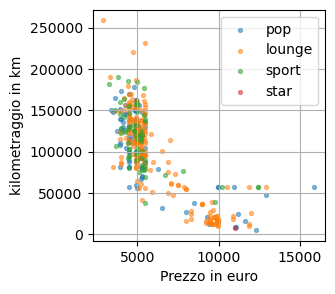

In [11]:
#Selezioniamo tutti gli allestimenti
fig, ax = plt.subplots(figsize=(3,3))
#un'immagine sola con più dati sopra, se volevo più immagini allora avrei dovuto fare axs
for model in model_list:
    selected_data = data[data["model"] == model]
    price = selected_data["price"].to_numpy() #Prendo la colonna dei prezzi e la metto in un array di numpy per poter fare grafici
    km = selected_data["km"].to_numpy()
    ax.scatter(price, km, s=8, alpha = 0.5, label=model)
ax.set_xlabel("Prezzo in euro")
ax.set_ylabel("kilometraggio in km")
ax.legend()
ax.grid()
plt.show()

Il modello rapporto-chilometraggio non dipende tanto dal modello, ma più dal kilometraggio ed il prezzo

### Grafico per latitudine e longitudine

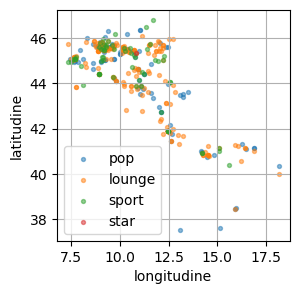

In [15]:
#Selezioniamo tutti gli allestimenti
fig, ax = plt.subplots(figsize=(3,3))
#un'immagine sola con più dati sopra, se volevo più immagini allora avrei dovuto fare axs
for model in model_list:
    selected_data = data[data["model"] == model]
    lat = selected_data["lat"].to_numpy() #Prendo la colonna dei prezzi e la metto in un array di numpy per poter fare grafici
    lon = selected_data["lon"].to_numpy()
    ax.scatter(lon, lat, s=8, alpha = 0.5, label=model)
ax.set_xlabel("longitudine")
ax.set_ylabel("latitudine")
ax.legend()
ax.grid()
plt.show()

#Sembra l'Italia, perchè è dove vengono vendute!!